# Random Forest

## słowa kluczowe:
las losowy, random forest, klasyfikacja wieloklasowa, drzewa decyzyjne, walidacja krzyżowa

## Opis metody
Las losowy (ang. Random Forest) to metoda polegająca na uśrednianiu wyników wielu głębokich drzew decyzyjnych, które są trenowane na różnych częściach tego samego zbioru treningowego. Głównym celem tego podejścia jest eliminacja problemu przeuczenia (ang. overfitting), który często występuje w przypadku pojedynczych drzew decyzyjnych.
Innymi słowy, lasy losowe stanowią metodę uczenia zespołowego (ang. ensemble learning) wykorzystywaną w zadaniach klasyfikacji i regresji. Algorytm ten działa poprzez konstruowanie wielu drzew decyzyjnych w fazie trenowania, a jego ostatecznym wynikiem w przypadku klasyfikacji jest klasa dominująca wśród wskazań uzyskanych z poszczególnych drzew.

## Działanie metody
 - Każde drzewo w lesie jest trenowane na podstawie około 2/3 wszystkich danych treningowych (dkładanie 63,2 %, ale u nas jest to 70%) Wybór przypadków jest losowy z wykorzystaniem oryginalnych danych. Ta próbka stanowi zbiór treningowy do rozbudowy drzewa.
 - Niektóre zmienne predykcyjne są losowo wybierane do rozważenia przy każdym podziale w drzewie. Zazwyczaj jest to pierwiastek kwadratowy z liczby wszystkich zmiennych predykcyjnych.
  - Dla kadego drzewa, wykorzystując pozostałe dane (36,8%, u nas dla uproszczenia 30 %) oblicza się wskaźnik błędu, który jest używany do oceny wydajności modelu (OOB).

   - Kazde drzewo klasyfikuje swoje dane OOB, a następnie porównuje przewidywania z rzeczywistymi etykietami, aby obliczyć wskaźnik błędu OOB. Ten wskaźnik jest używany do oceny wydajności modelu i może być wykorzystany do dostrajania hiperparametrów.

In [4]:
# Import bibliotek
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

In [5]:
# Pobranie danych
pokemonyMain = pd.read_csv("pokemonyMain_groups.csv")
pokemonyMain_las = pokemonyMain.copy()

Wybieram zestaw cech opisujacych statystyki oraz parametry Pokemonów na których będziemy operować

In [6]:
# Obsługa braków danych
pokemonyMain_las = pokemonyMain_las.dropna(subset=[
    "weight",
    "catch_rate",
    "base_exp",
    "group"
])

In [8]:
# Uuzupełnienie brakow w egg_cycles
pokemonyMain_las["egg_cycles"] = pokemonyMain_las["egg_cycles"].fillna(pokemonyMain_las["egg_cycles"].median())

cechy = pokemonyMain_las[[
    "hp",
    "attack",
    "defense",
    "spatk",
    "spdef",
    "speed",
    "height",
    "weight",
    "catch_rate",
    "base_exp",
    "egg_cycles"
]]
etykieta = pokemonyMain_las["group"]

W celu zapewnienia pełnej spójności danych pomiędzy testowanymi modelami, zaimplementowałam procedurę usuwania obserwacji z brakującymi wartościami. Za pomocą funkcji `dropna()` zdefiniowano podzbiór zmiennych krytycznych, takich jak masa, wskaźnik złapania, bazowe doświadczenie oraz zmienna objaśniana (grupa docelowa). Wiersze zawierające puste pola (`NaN`) w tych konkretnych kolumnach zostały wykluczone z dalszej analizy, co zapobiega wystąpieniu błędów podczas fazy uczenia algorytmów.

In [19]:
cecha_train_las, cecha_test_las, etykieta_train_las, etykieta_test_las = train_test_split(
    cechy,
    etykieta,
    test_size=0.3,
    random_state=42
)

Dane zostały podzielone na zbiór treningowy (70%) oraz testowy (30%) w celu oceny skuteczności modelu.

### Walidacja krzyżowa (Cross-Validation)
Przed ostatecznym wytrenowaniem modelu, przeprowadzam 5-krotną walidację krzyżową na zbiorze treningowym, aby upewnić się, że model stabilnie klasyfikuje dane.

In [11]:
# Inicjalizacja modelu
modelLas = RandomForestClassifier(n_estimators=100, random_state=42)

kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(modelLas, cecha_train_las, etykieta_train_las, cv=kf, scoring='accuracy')

print(f"Wyniki poszczególnych przebiegów walidacji: {cv_scores}")
print(f"Średnia dokładność w walidacji krzyżowej: {cv_scores.mean() * 100:.2f}%")

Wyniki poszczególnych przebiegów walidacji: [0.5748503  0.53293413 0.5508982  0.56024096 0.5060241 ]
Średnia dokładność w walidacji krzyżowej: 54.50%


### Trenowanie modelu lasu losowego

Komenda `modelLas.fit()` odpowiada za przeprowadzenie właściwego procesu trenowania algorytmu Lasu Losowego na wyodrębnionym zbiorze treningowym (`cecha_train_las`, `etykieta_train_las`). Na tym etapie algorytm buduje strukturę złożoną ze 100 niezależnych drzew decyzyjnych, wykorzystując technikę agregacji bootstrapowej (Bagging) oraz losową selekcję cech w węzłach. Model analizuje korelacje pomiędzy parametrami numerycznymi obiektów a ich rzeczywistą przynależnością do klas, optymalizując wewnętrzne reguły podziału w celu zminimalizowania błędu klasyfikacji. Po wykonaniu tej operacji model uzyskuje zdolność do predykcji.

In [12]:
modelLas.fit(cecha_train_las, etykieta_train_las)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

### Macierz błędów klasyfikacji dla zbioru treningowego

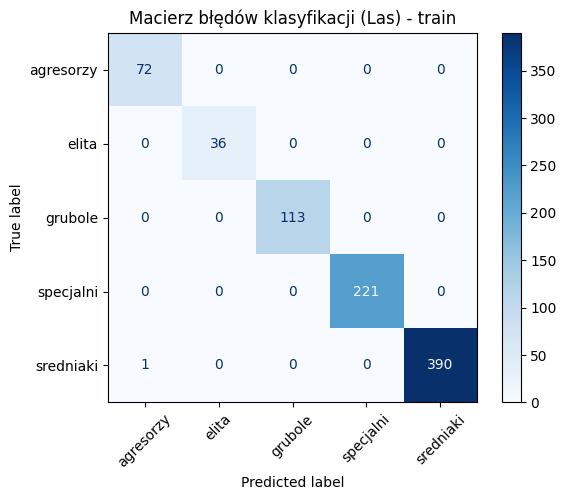

In [13]:
predykcja_train_las = modelLas.predict(cecha_train_las)
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_train_las,
    predykcja_train_las,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji (Las) - train")
plt.savefig("confusion_matrix_train_las.png", dpi=300, bbox_inches="tight")
plt.show()

### Dokładność modelu zbiór - testowy

In [15]:
predykcja_test_las = modelLas.predict(cecha_test_las)
print("Dokladnosc:", accuracy_score(etykieta_test_las, predykcja_test_las))
procent_poprawnych = accuracy_score(etykieta_test_las, predykcja_test_las) * 100
print(f"Procent poprawnych wyników: {procent_poprawnych:.2f}%")

Dokladnosc: 0.5921787709497207
Procent poprawnych wyników: 59.22%


In [21]:
wyniki = cecha_test_las.copy()

wyniki["prawdziwa_grupa"] = etykieta_test_las.values
wyniki["przewidziana_grupa"] = predykcja_test_las

wyniki["pokemon"] = pokemonyMain_las.loc[cecha_test_las.index, "name"].values

print(wyniki[["pokemon", "prawdziwa_grupa", "przewidziana_grupa"]].head(20))

           pokemon prawdziwa_grupa przewidziana_grupa
953      pheromosa       sredniaki          specjalni
247          yanma       sredniaki          sredniaki
260         pineco       sredniaki          sredniaki
155         horsea       sredniaki          sredniaki
566      rhyperior         grubole            grubole
549   lucario-mega       agresorzy          sredniaki
803        flabebe       specjalni          specjalni
58       vileplume       sredniaki          sredniaki
753       braviary       sredniaki          sredniaki
644         audino       sredniaki          sredniaki
613       oshawott       sredniaki          specjalni
746      druddigon           elita            grubole
716       frillish       sredniaki          sredniaki
572        leafeon       sredniaki            grubole
380       meditite       agresorzy          sredniaki
70         persian       sredniaki          sredniaki
523       drifloon       specjalni          sredniaki
823        malamar       agr

### Macierz błędów klasyfikacji dla zbioru testowego

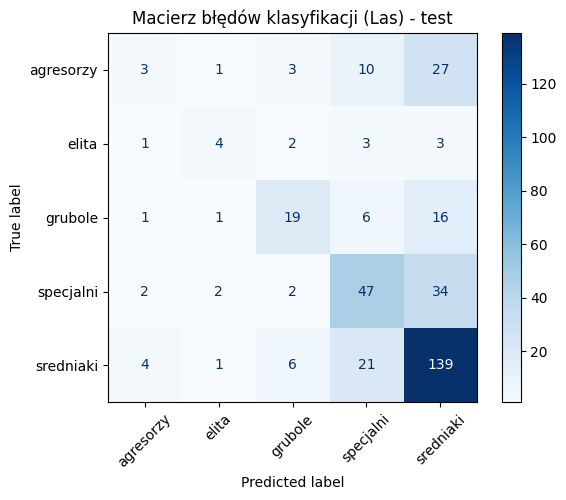

In [17]:
disp = ConfusionMatrixDisplay.from_predictions(
    etykieta_test_las,
    predykcja_test_las,
    cmap="Blues",
    xticks_rotation=45
)

plt.title("Macierz błędów klasyfikacji (Las) - test")
plt.savefig("confusion_matrix_test_las.png", dpi=300, bbox_inches="tight")
plt.show()

### Przykład użycia modelu na sztucznej obserwacji

In [22]:
sztuczny_pokemon = pd.DataFrame([{
    "hp": 90,
    "attack": 110,
    "defense": 80,
    "spatk": 100,
    "spdef": 85,
    "speed": 95,
    "height": 1.6,
    "weight": 65.0,
    "catch_rate": 45.0,
    "base_exp": 240.0,
    "egg_cycles": 25.0
}])

klasa_sztuczna = modelLas.predict(sztuczny_pokemon)
prawdopodobienstwa = modelLas.predict_proba(sztuczny_pokemon)

print(f"Klasyfikacja sztucznego Pokemona: {klasa_sztuczna[0]}")
print("Prawdopodobieństwa przypisania do grup:")
for klasa, prob in zip(modelLas.classes_, prawdopodobienstwa[0]):
    print(f" - {klasa}: {prob*100:.2f}%")

Klasyfikacja sztucznego Pokemona: specjalni
Prawdopodobieństwa przypisania do grup:
 - agresorzy: 10.00%
 - elita: 2.00%
 - grubole: 7.00%
 - specjalni: 49.00%
 - sredniaki: 32.00%


Wprowadzenie sztucznej obserwacji (tzw. obiektu syntetycznego) polega na przetestowaniu ostatecznej wersji algorytmu na całkowicie nowym, hipotetycznym obiekcie, który nie występował w pierwotnym zbiorze danych. Na potrzeby tej weryfikacji zdefiniowano unikalny profil Pokemona o sprecyzowanych, autorskich statystykach bojowych oraz parametrach rozwoju. Operacja ta pozwala zasymulować realne działanie modelu w warunkach produkcyjnych oraz ocenić, czy algorytm podejmuje logiczne decyzje klasyfikacyjne w zderzeniu z nowymi, nieznanymi wcześniej strukturami danych, co bezpośrednio realizuje praktyczne założenia projektu.

### Bibliografia
Breiman, L. (2001). Random Forests. *Machine Learning*, https://doi.org/10.1023/A:1010933404324

https://www.listendata.com/2014/11/random-forest-with-r.html - definicja i działanie lasu losowego

prezentacja: Wykład 6 - Wzmacnianie klasyfikatorów
dr hab. Konrad Furmańczyk, prof. SGGW, Instytut Informatyki Technicznej, November 9, 2021